In [2]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

carga del dataset

In [3]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  
    transforms.Resize((48, 48)),                 
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dir = "./train"
test_dir = "./test"

trainset = datasets.ImageFolder(root=train_dir, transform=transform)
testset = datasets.ImageFolder(root=test_dir, transform=transform)

classes = trainset.classes
print("Clases:", classes)
print("Cantidad en train:", len(trainset))
print("Cantidad en test:", len(testset))




Clases: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Cantidad en train: 28709
Cantidad en test: 7178


dataloader


In [4]:
dataloader = {
    'train': DataLoader(trainset, batch_size=32, shuffle=True),
    'val': DataLoader(testset, batch_size=1000, shuffle=False)
}

In [5]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1, keepdims=True)

def build_model(D_in=48*48, H1=1500, H2=750, H3=375, D_out=7, p=0.5):
    return torch.nn.Sequential(
        torch.nn.Flatten(),
        torch.nn.Linear(D_in, H1),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H1, H2),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H2, H3),
        torch.nn.ReLU(),
        torch.nn.Dropout(p),  
        
        torch.nn.Linear(H3, D_out)
    )




funcion de entrenamiento

In [7]:
def fit(model, dataloader, optimizer, epochs=100, log_each=10, weight_decay=0, early_stopping=10):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc = [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0

    for e in range(1, epochs+1):
        _l, _acc = [], []
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(y_pred, axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))

        # evaluación en validación
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(y_pred, axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))

        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')  # solo pesos
            step = 0
            print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1

        # early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break

        if not e % log_each:
            print(f"Epoch {e}/{epochs} | loss {l[-1]:.5f} acc {acc[-1]:.5f} | val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f}")

    # cargar mejor modelo de forma segura
    model.load_state_dict(torch.load('ckpt.pt', weights_only=True))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc}


sgd


In [8]:

model = build_model(D_in=48*48,H1=1500, H2=750, H3=375, D_out=len(classes),p=0.5)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
hist_sgd = fit(model, dataloader, optimizer)


KeyboardInterrupt: 

momentun

In [7]:
model = build_model(D_in=48*48, H1=1500, H2=750, H3=375, D_out=len(classes),p=0.5)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
hist_momentum = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.37121 en epoch 1
Mejor modelo guardado con acc 0.37917 en epoch 2
Mejor modelo guardado con acc 0.38230 en epoch 5
Mejor modelo guardado con acc 0.39511 en epoch 6
Mejor modelo guardado con acc 0.40781 en epoch 7
Mejor modelo guardado con acc 0.42286 en epoch 9
Mejor modelo guardado con acc 0.43151 en epoch 10
Epoch 10/100 | loss 1.49824 acc 0.41672 | val_loss 1.49006 val_acc 0.43151
Mejor modelo guardado con acc 0.43993 en epoch 14
Mejor modelo guardado con acc 0.44865 en epoch 20
Epoch 20/100 | loss 1.38134 acc 0.46524 | val_loss 1.44576 val_acc 0.44865
Mejor modelo guardado con acc 0.45373 en epoch 23
Mejor modelo guardado con acc 0.45731 en epoch 26
Mejor modelo guardado con acc 0.46497 en epoch 28
Epoch 30/100 | loss 1.27446 acc 0.51011 | val_loss 1.46690 val_acc 0.45100
Mejor modelo guardado con acc 0.46510 en epoch 32
Mejor modelo guardado con acc 0.47732 en epoch 40
Epoch 40/100 | loss 1.19076 acc 0.54827 | val_loss 1.44231 val_acc 0.47732
Entren

 RMSprop

In [10]:
model = build_model(D_in=48*48, H1=1500, H2=750, H3=375, D_out=len(classes),p=0.5)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)
hist_rms = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.22175 en epoch 1
Epoch 10/100 | loss 1.81092 acc 0.25127 | val_loss 1.84659 val_acc 0.22175
Entrenamiento detenido en epoch 11 por no mejorar en 10 epochs seguidas


ADAM

In [11]:
model = build_model(D_in=48*48, H1=1500, H2=750, H3=375, D_out=len(classes),p=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
hist_adam = fit(model, dataloader, optimizer)

Mejor modelo guardado con acc 0.22175 en epoch 1
Epoch 10/100 | loss 1.81080 acc 0.25127 | val_loss 1.85073 val_acc 0.22175
Entrenamiento detenido en epoch 11 por no mejorar en 10 epochs seguidas


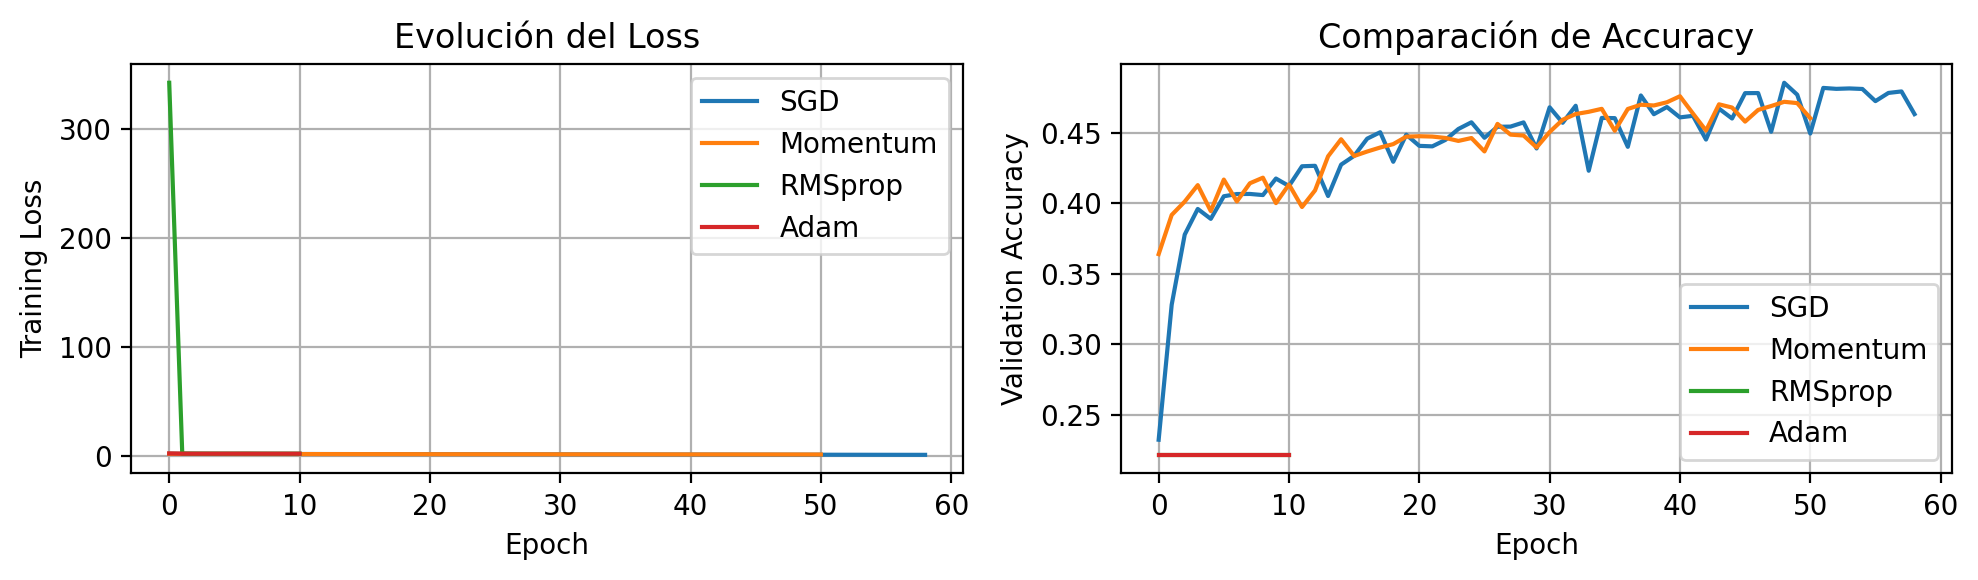

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(dpi=200, figsize=(10,3))

# Curvas de pérdida (loss)
ax = plt.subplot(121)
ax.plot(hist_sgd['loss'], label="SGD")
ax.plot(hist_momentum['loss'], label="Momentum")
ax.plot(hist_rms['loss'], label="RMSprop")
ax.plot(hist_adam['loss'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title("Evolución del Loss")

# Curvas de accuracy en validación
ax = plt.subplot(122)
ax.plot(hist_sgd['val_acc'], label="SGD")
ax.plot(hist_momentum['val_acc'], label="Momentum")
ax.plot(hist_rms['val_acc'], label="RMSprop")
ax.plot(hist_adam['val_acc'], label="Adam")
ax.legend()
ax.grid(True)
ax.set_ylabel('Validation Accuracy')
ax.set_xlabel('Epoch')
ax.set_title("Comparación de Accuracy")

plt.tight_layout()
plt.show()


adam

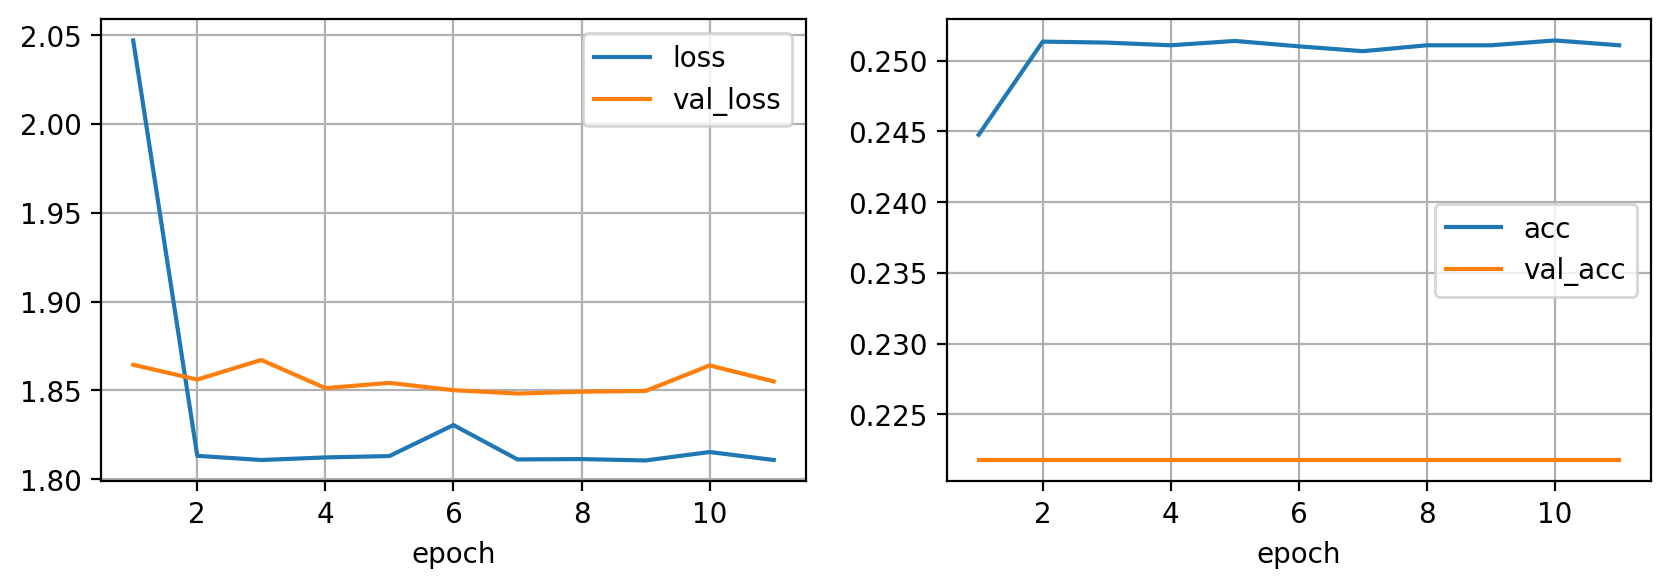

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_adam).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_adam).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

momentum

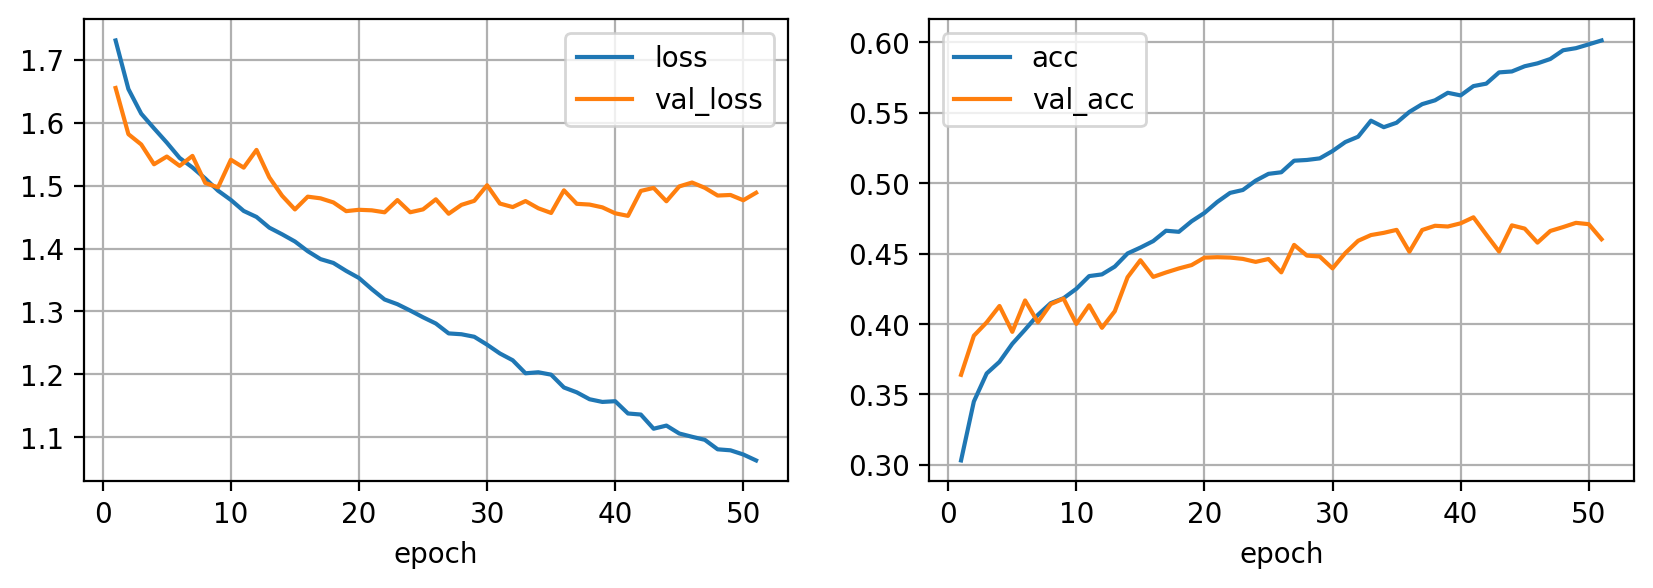

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_momentum).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

rms

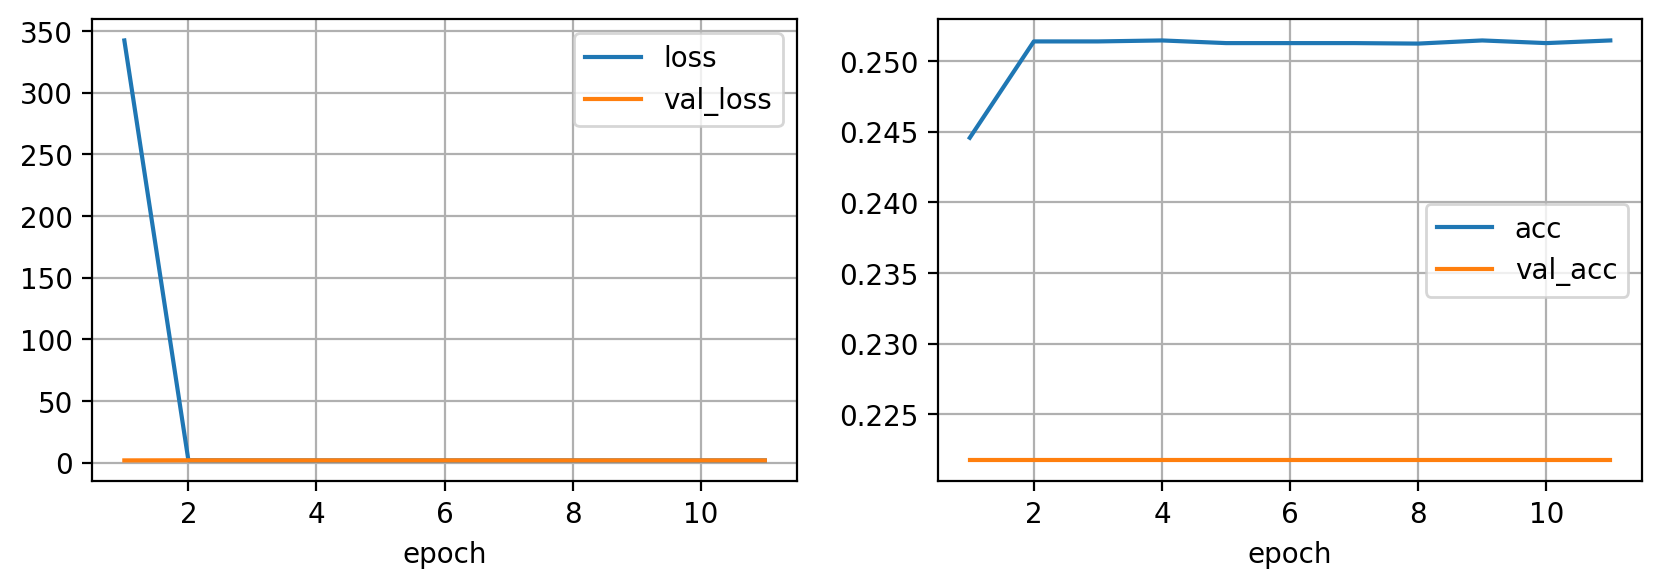

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_rms).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_rms).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()

sgd

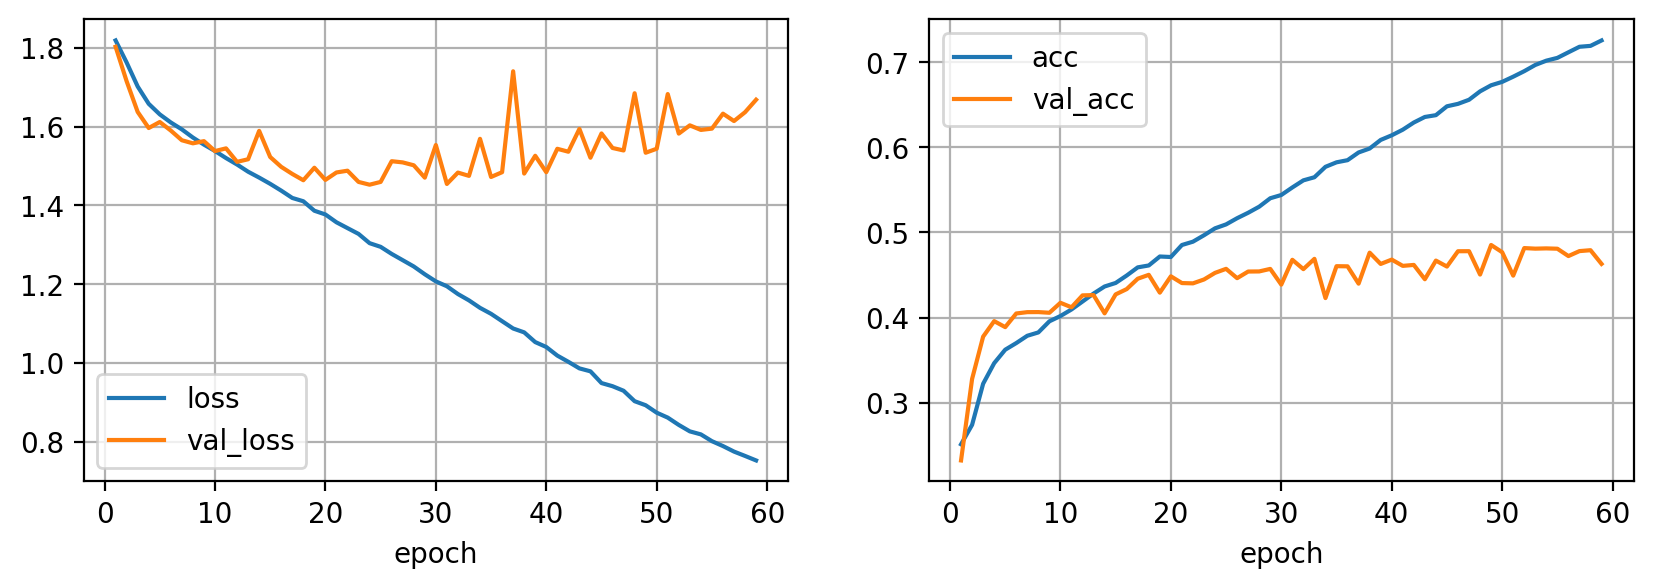

In [ ]:
import pandas as pd

fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['loss', 'val_loss'], grid=True, ax=ax)
ax = plt.subplot(122)
pd.DataFrame(hist_sgd).plot(x='epoch', y=['acc', 'val_acc'], grid=True, ax=ax)
plt.show()